# Section 2: Data Preparation & Feature Engineering  --> Chapter 5: Data Comprehension

---
---

**Book: Applied Machine Learning for Data Science Practitioners**
<BR>

**Author:** Vidya Subramanian (https://www.linkedin.com/in/vidyas/)

**Note:** Code is only included here for the steps that require it. Please refer to the book for the complete set of steps related to the goals covered in the chapter.

---
---

---

☑ **Install libraries**

---

In [ ]:
# In case you need to install the relevent packages, please run these (once only)

!pip install scikit-learn==1.2.2
# !pip install pandas==2.0.3
# !pip install numpy==1.25.2
# !pip install requests==2.31.0

!pip install google.colab
!pip install pydrive2==1.6.3
!pip install oauth2client==4.1.3
# !pip install fitter==1.7.0
!pip install stemgraphic
!pip install tabulate
# !pip install locale
# !pip install itertools

In [ ]:
!pip install fitter==1.7.0

---

☑ **Import libraries**

---

In [ ]:
# Set some common environment variables and Imports
import numpy as np
import pandas as pd  # Import pandas module for data manipulation
import warnings  # Warnings

from IPython.core.display import display, HTML  # Make the Jupyter chunk window wider
from pydrive2.auth import GoogleAuth  # Import GoogleAuth class from the pydrive2.auth module
from pydrive2.drive import GoogleDrive  # Import GoogleDrive class from the pydrive2.drive module
from google.colab import auth  # Import auth class from the google.colab module
from oauth2client.client import GoogleCredentials  # Import GoogleCredentials class from the oauth2client.client module

from IPython.core.display import display, HTML  # Import display and HTML classes from the IPython.core.display module
from tabulate import tabulate  # Adjust CSS style for output wrapper to prevent text wrapping in preformatted text

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter
import matplotlib.patches as patches
from matplotlib.axis import Axis

import math
from fitter import Fitter, get_common_distributions, get_distributions
import scipy.stats as stats
from scipy.stats import skew, kurtosis, chi2_contingency
import locale
from statsmodels.graphics.mosaicplot import mosaic
from itertools import cycle

# Initialize logging
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

## 1.1 Data Analysis


###**Step 1a:** Extract the data since we are starting a new chapter in a new code file.

In [ ]:
# ***** Function to help display*****
def print_pretty_header(title, subtitle):
    # Define header formatting
    line_length = 50
    header_padding = 2
    # Calculate the width for the title text
    title_width = line_length  * header_padding
    print("#" * title_width + "\n")
    print(title.center(title_width) + "\n")
    if subtitle:
        # Calculate the width for the subtitle text
        subtitle_width = line_length - 2 * header_padding
        print(subtitle.center(title_width)+ "\n")
    print("#" * title_width + "\n")

#### a. Read from Google Colab

In [ ]:
def get_data(colabFileName, fileLink):
    try:
        # Authenticate and create the PyDrive client.
        auth.authenticate_user()  # Authenticate the user
        gauth = GoogleAuth()  # Create a GoogleAuth instance
        gauth.credentials = GoogleCredentials.get_application_default()  # Use the default application credentials
        drive = GoogleDrive(gauth)  # Create a GoogleDrive instance using the authenticated GoogleAuth instance

        # Read File
        ignorestr, id = fileLink.split('=')  # Split the link by '=' and get the id of the file
        downloaded = drive.CreateFile({'id':id})  # Create a PyDrive File instance with the specified file id
        downloaded.GetContentFile(colabFileName)  # Download the file and save it to the local file system
        df = pd.read_csv(colabFileName)  # Read the CSV file into a Pandas dataframe
        return df  # Return the Pandas dataframe
    except Exception as e:
        logging.error(f"Failed to get data: {e}")
        raise
        return None

# Read the file and display contents.
print_pretty_header("Extract Data for Data Analysis, Comprehension, and EDA", "All Data")
colabFileName = 'S2_Ch5_Data_Comprehension_data.csv'  # Define the filename
dataLink = 'https://drive.google.com/open?id=1l5ymRC8pnBy46NyH03y-BOa78-oyr8Q0'  # The shareable link to the file
df_rawdata = get_data(colabFileName, dataLink)  # Call the get_data() function
df_rawdata_org = df_rawdata.copy()  # Make a copy of the Pandas dataframe for ease of dropping columns
df_rawdata  # Display the Pandas dataframe containing the data.

####################################################################################################

                       Extract Data for Data Analysis, Comprehension, and EDA                       

                                              All Data                                              

####################################################################################################



,VacationHomeID,VacHomeClass,VacHomeZone,VacHomeLotFrontage,VacHomeLotSqFt,VacHomeStreet,VacHomeRoad,VacHomeLotShape,VacHomeLandContour,VacHomeUtilities,...,VacHomeOwnerCountry,VacHomeOwnerEmail,VacHomeOwnerGender,VacHomeOwnerState,VacHomeOwnerZipcode,VacHomeRenovationAmount,VacHomeSurveyDate,VacHomeSurveyRating,VacHomeReviewDate,VacHomeReviewRating
0,1,VacHomeClass-6,VacHomeZone-1,65.0,8450,Cobblestone,Gravel,Pie,Flat,Trash|Gas|Water|Electricity,...,Venezuela,sylvester59@haase.de,M,Niedersachsen,41157,93.0,2021-11-24,4.6,2021-11-24,4.6
1,2,VacHomeClass-1,VacHomeZone-1,80.0,9600,Cobblestone,Gravel,Pie,Flat,Trash|Gas|Water|Electricity,...,Bolivien,tilman19@junck.org,F,Thüringen,84185,9.0,2021-01-16,3.8,2021-01-16,3.8
2,3,VacHomeClass-6,VacHomeZone-1,68.0,11250,Cobblestone,Gravel,Reverse Pie,Flat,Trash|Gas|Water|Electricity,...,Pakistan,erich35@kade.com,M,Rheinland-Pfalz,79533,88.0,2021-07-08,4.4,2021-07-08,4.4
3,4,VacHomeClass-7,VacHomeZone-1,60.0,9550,Cobblestone,Gravel,Reverse Pie,Flat,Trash|Gas|Water|Electricity,...,Thailand,burkardpaertzelt@googlemail.com,F,Brandenburg,13145,94.0,2021-07-05,3.9,2021-07-05,3.9
4,5,VacHomeClass-6,VacHomeZone-1,84.0,14260,Cobblestone,Gravel,Reverse Pie,Flat,Trash|Gas|Water|Electricity,...,Portugal,kaesterjoana@aol.de,F,Nordrhein-Westfalen,64280,37.0,2021-12-13,2.8,2021-12-13,2.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,VacHomeClass-6,VacHomeZone-1,62.0,7917,Cobblestone,Gravel,Pie,Flat,Trash|Gas|Water|Electricity,...,Isle of Man,erdal97@schuchhardt.de,F,Berlin,5310,61.0,2021-05-08,3.5,2021-05-08,3.5
1456,1457,VacHomeClass-1,VacHomeZone-1,85.0,13175,Cobblestone,Gravel,Pie,Flat,Trash|Gas|Water|Electricity,...,Katar,kuehnertanna-luise@dippel.com,M,Sachsen-Anhalt,42804,31.0,2021-11-15,1.4,2021-11-15,1.4
1457,1458,VacHomeClass-7,VacHomeZone-1,66.0,9042,Cobblestone,Gravel,Pie,Flat,Trash|Gas|Water|Electricity,...,Svalbard und Jan Mayen,eminotto@gmail.com,Unknown,Hessen,1482,60.0,2021-08-08,2.5,2021-08-08,2.5
1458,1459,VacHomeClass-1,VacHomeZone-1,68.0,9717,Cobblestone,Gravel,Pie,Flat,Trash|Gas|Water|Electricity,...,Kuwait,sina70@karge.net,M,Rheinland-Pfalz,67129,62.0,2021-01-15,1.9,2021-01-15,1.9


###**Step 1b:** Bifurcate the training set to analyze.

In [ ]:
# Calculate the number of rows needed for the training set (50%)
training_size = len(df_rawdata) // 2

# Slice the data to create the training and test sets
df_train_data = df_rawdata.iloc[:training_size]  # Selecting the first half of the data for training
df_test_data = df_rawdata.iloc[training_size:]   # Selecting the second half of the data for testing

# Print the shapes of the resulting dataframes
print_pretty_header("Splitting data for Generalization", "Shape of Bifurcated datasets")
print(f"Train Data Shape: {df_train_data.shape}")  # Displaying the shape of the training data
print(f"Test Data Shape: {df_test_data.shape}")    # Displaying the shape of the testing data


####################################################################################################

                                 Splitting data for Generalization                                  

                                    Shape of Bifurcated datasets                                    

####################################################################################################

Train Data Shape: (730, 79)
Test Data Shape: (730, 79)


###**Step 1c:** Manually review the columns.

In [ ]:
# Print the shapes of the resulting dataframes
print_pretty_header("List of Columns in training data", "")
df_train_data.info(0)

####################################################################################################

                                  List of Columns in training data                                  

####################################################################################################

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 79 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   VacationHomeID            730 non-null    int64  
 1   VacHomeClass              730 non-null    object 
 2   VacHomeZone               730 non-null    object 
 3   VacHomeLotFrontage        606 non-null    float64
 4   VacHomeLotSqFt            730 non-null    int64  
 5   VacHomeStreet             730 non-null    object 
 6   VacHomeRoad               730 non-null    object 
 7   VacHomeLotShape           730 non-null    object 
 8   VacHomeLandContour        730 non-

### **Step 1d:** Categorize the columns based on datatype.

In [ ]:
# Manually created lists
continuous_columns  = ["VacHomeLotFrontage", "VacHomeLotSqFt", "VacHomeBsmtSqFt", "VacHomeFloor1SqFt", "VacHomeFloor2SqFt", "VacHomeSqFt", "VacHomeMasonryArea", "VacHomeGarageArea",
                       "VacHomeWoodDeckSqFt", "VacHomePorchSqFt", "VacHomePoolSqFt", "VacHomeSalePrice", "VacHomeRenovationAmount"]
nominal_columns     = ["VacHomeClass", "VacHomeZone", "VacHomeLotShape", "VacHomeLandContour", "VacHomeUtilities", "VacHomeLotConfig", "VacHomeLandSlope", "VacHomeNeighborhood", "VacHomeCondition",
                       "VacHomeBuilding", "VacHomeHouseStyle", "VacHomeRoofStyle", "VacHomeRoofMat", "VacHomeExterior", "VacHomeMasonryVeneer", "VacHomeFoundation", "VacHomeBsmtLight",
                       "VacHomeBsmtFinish", "VacHomeHeating", "VacHomeAC", "VacHomeElectricalWiring", "VacHomeGarageType", "VacHomeGarageFinish", "VacHomeDriveway", "VacHomeFence", "VacHomeSaleType",
                       "VacHomeSaleCondition", "VacHomeInterestInHome", "VacHomeGoodSchools", "VacHomeOwnerGender", "VacHomeOwnerState", "VacHomeOwnerZipcode", "VacHomeOwnerCity", "VacHomeOwnerCountry"]
discrete_columns    = ["VacHomeNumFullBath", "VacHomeNumHalfBath", "VacHomeBedroomWithCloset", "VacHomeKitcheninHome", "VacHomeRooms", "VacHomeFireplaces", "VacHomeCarsInGarage"]
ordinal_columns     = ["VacHomeRating", "VacHomeQuality", "VacHomeExterQual", "VacHomeQual", "VacHomeBsmtQuality", "VacHomeHeatingQuality", "VacHomeKitchenQuality", "VacHomeFireplaceQuality",
                       "VacHomeGarageQuality", "VacHomePoolQuality", "VacHomeSurveyRating","VacHomeReviewRating"]
ignore_columns      = ["VacationHomeID", "VacHomeStreet", "VacHomeRoad", "VacHomeConsYear", "VacHomeSince", "VacHomeStartMonth", "VacHomeStartYear", "VacHomeAvailableDate", "VacHomeBarCode",
                       "VacHomeOwnerAddress", "VacHomeOwnerEmail", "VacHomeSurveyDate","VacHomeReviewDate"]

# Find the lengths of the lists
length_continuous = len(continuous_columns)
length_nominal = len(nominal_columns)
length_discrete = len(discrete_columns)
length_ordinal = len(ordinal_columns)
length_ignore = len(ignore_columns)

# Create a list with header columns
header_columns = [str(length_continuous) + " Continuous Columns", str(length_nominal) +  " Nominal Columns", str(length_discrete) + " Discrete Columns", str(length_ordinal) + " Ordinal Columns", str(length_ignore) + " Ignore Columns"]

# Calculate the maximum number of columns
max_columns = max(len(continuous_columns), len(nominal_columns), len(discrete_columns), len(ordinal_columns), len(ignore_columns))

# Specify the table format you want, e.g., "grid", "fancy_grid", "pretty", "pipe", "html", etc.
table_format = "fancy_grid"

# Create a list of lists with columns
table_data = []

# Combine all column names into a single string with newline characters for each data type
continuous_columns_list = "\n".join(continuous_columns)
nominal_columns_list = "\n".join(nominal_columns)
discrete_columns_list = "\n".join(discrete_columns)
ordinal_columns_list = "\n".join(ordinal_columns)
ignore_columns_list = "\n".join(ignore_columns)

# Append the lists of column names to the table data list
table_data.append([continuous_columns_list, nominal_columns_list, discrete_columns_list, ordinal_columns_list, ignore_columns_list])

# Print the table with tabulate
print_pretty_header("List of Columns in training data by Data Type", "")
print(tabulate(table_data, headers=header_columns, tablefmt="grid"))


####################################################################################################

                           List of Columns in training data by Data Type                            

####################################################################################################

+-------------------------+-------------------------+--------------------------+-------------------------+----------------------+
| 13 Continuous Columns   | 34 Nominal Columns      | 7 Discrete Columns       | 12 Ordinal Columns      | 13 Ignore Columns    |
+=========================+=========================+==========================+=========================+======================+
| VacHomeLotFrontage      | VacHomeClass            | VacHomeNumFullBath       | VacHomeRating           | VacationHomeID       |
| VacHomeLotSqFt          | VacHomeZone             | VacHomeNumHalfBath       | VacHomeQuality          | VacHomeStreet        |
| VacHomeBsmtSqFt         | VacHomeLotShape 

## 1.2. Data Profiling
We've worked hard on extracting our data and now we're ready to explore! First, let’s check the data to see what data quality challenges we will be up against.


### 1.2.1. Data Quality Check

#### **Step 2a:** Create HeatMap to visualize missing data.

####################################################################################################

                                       Missing Data Heat Map                                        

####################################################################################################



<ipython-input-9-39cee131d9ce>:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  original_colormap = plt.cm.get_cmap('RdYlGn')


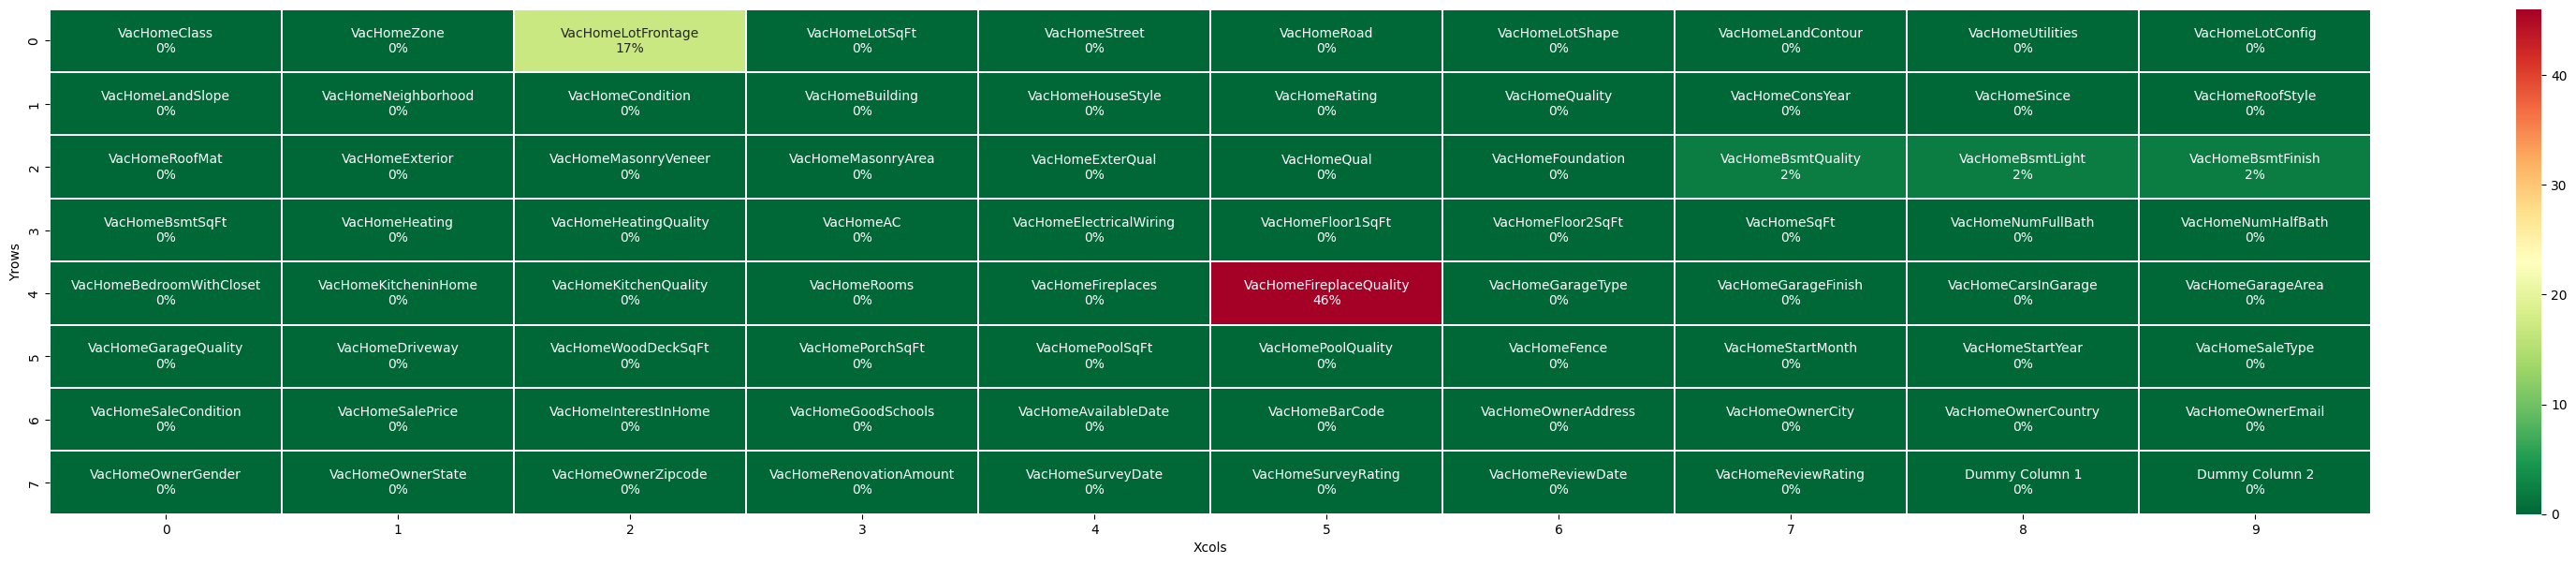

In [ ]:
def create_heatmap(df):
    try:
        # Create a heatmap from a DataFrame
        heatmap_columns = 10
        heatmap_rows = 8

        df_heatmap = df.copy()
        df_heatmap.insert(loc=79, column='Dummy Column 1', value=1)
        df_heatmap.insert(loc=80, column='Dummy Column 2', value=1)

        columns = df_heatmap.columns
        null_percentages = [math.trunc(round((df_heatmap[column].isnull().sum() / df_heatmap.shape[0]), 2) * 100) for column in columns]

        missing_data_df = pd.DataFrame({'Variable': columns, 'Null Percent': null_percentages})
        missing_data_df = missing_data_df.iloc[1:]

        variable_array = np.array(missing_data_df['Variable']).reshape(heatmap_rows, heatmap_columns)
        null_percent_array = np.array(missing_data_df['Null Percent']).reshape(heatmap_rows, heatmap_columns)

        missing_data_df['Yrows'] = np.arange(len(missing_data_df)) // 10
        missing_data_df['Xcols'] = missing_data_df.groupby(['Yrows']).cumcount()

        missing_data_df.set_index(['Variable', 'Null Percent']).unstack()
        result = missing_data_df.pivot(index='Yrows', columns='Xcols', values='Null Percent')

        labels = np.array([f"{variable}\n{null_percent}%" for variable, null_percent in zip(variable_array.flatten(), null_percent_array.flatten())]).reshape(heatmap_rows, heatmap_columns)

        return result, labels
    except Exception as e:
        logging.error(f"Failed to create heatmap: {e}")
        raise
        return None

def reverse_colourmap(cmap, name='reversed_cmap'):
    try:
        # Function to reverse a colormap
        reverse = []
        color_channels = []

        for channel_key in cmap._segmentdata:
            color_channels.append(channel_key)
            channel_data = cmap._segmentdata[channel_key]
            reversed_data = []

            for color_segment in channel_data:
                reversed_data.append((1 - color_segment[0], color_segment[2], color_segment[1]))
            reverse.append(sorted(reversed_data))

        LinearL = dict(zip(color_channels, reverse))
        reversed_cmap = mpl.colors.LinearSegmentedColormap(name, LinearL)
        return reversed_cmap
    except Exception as e:
        logging.error(f"Failed to reverse colourmap: {e}")
        raise
        return None

def plot_heatmap(result, labels):
    try:
        # Function to plot the heatmap
        original_colormap = plt.cm.get_cmap('RdYlGn')
        reversed_colormap = reverse_colourmap(original_colormap)

        figure, axis = plt.subplots(figsize=(40, 7))
        heatmap_title = ""
        plt.title(heatmap_title, fontsize=18)
        title = axis.title
        title.set_position([0.5, 1.05])
        axis.set_xticks([])
        axis.set_yticks([])

        axis = sns.heatmap(result, annot=labels, fmt="", cmap=reversed_colormap, linewidths=0.30, ax=axis)
        plt.show()
    except Exception as e:
        logging.error(f"Failed to plot heatmap: {e}")
        raise
        return None

# Example usage:
result, labels = create_heatmap(df_train_data)
print_pretty_header("Missing Data Heat Map", "")
plot_heatmap(result, labels)


#### **Step 2b:** Create a list of fields missing data.

In [ ]:
# Initialize a dictionary to store missing columns
missing_columns = {data_type: [] for data_type in ['Continuous', 'Nominal', 'Discrete', 'Ordinal', 'Ignore']}

# Iterate through df_train_data columns and find missing columns
for col in df_train_data.columns:
    pct_missing = df_train_data[col].isnull().sum() / len(df_train_data)

    if round(pct_missing * 100) > 0:
        if col in continuous_columns:
            data_type = 'Continuous'
        elif col in nominal_columns:
            data_type = 'Nominal'
        elif col in discrete_columns:
            data_type = 'Discrete'
        elif col in ordinal_columns:
            data_type = 'Ordinal'
        elif col in ignore_columns:
            data_type = 'Ignore'
        else:
            data_type = 'Unknown'

        missing_columns[data_type].append(col)

# Print the missing columns categorized by data type
print_pretty_header("Missing Data in a list", "")
no_missing = True  # Flag to check if there are no missing columns

for data_type, columns in missing_columns.items():
    if columns:
        no_missing = False  # Set the flag to False if there are missing columns
        print("----------------------------")
        print(data_type + " Columns:")
        print("----------------------------")
        for col in columns:
            pct_missing = df_train_data[col].isnull().sum() / len(df_train_data)
            print(f"- {col}: {df_train_data[col].isnull().sum()} missing ({round(pct_missing * 100)}%)")

if no_missing:
    print("None")  # Print "None" if there are no missing columns


####################################################################################################

                                       Missing Data in a list                                       

####################################################################################################

----------------------------
Continuous Columns:
----------------------------
- VacHomeLotFrontage: 124 missing (17%)
----------------------------
Nominal Columns:
----------------------------
- VacHomeBsmtLight: 17 missing (2%)
- VacHomeBsmtFinish: 17 missing (2%)
----------------------------
Ordinal Columns:
----------------------------
- VacHomeBsmtQuality: 17 missing (2%)
- VacHomeFireplaceQuality: 336 missing (46%)


#### **Step 2c:** Find Missing Data above 20% Threshold

In [ ]:
# Print the missing columns categorized by data type
print_pretty_header("Columns with Missing Data above 20% Threshold", "")

for col in df_train_data.columns:
    pct_missing = df_train_data[col].isnull().sum()/ len(df_train_data[col].index)

    if round(pct_missing*100) > 20:
        print("Number of missing values in : " + '{} - {}% '.format(col,  round(pct_missing*100)) + "(" + str(df_train_data[col].isnull().sum()) + " Observations)")

####################################################################################################

                           Columns with Missing Data above 20% Threshold                            

####################################################################################################

Number of missing values in : VacHomeFireplaceQuality - 46% (336 Observations)


### 1.2.2. Check Data Distribution

#### **Step 2d:** Review the data distribution.

2024-12-24 13:16:48.802 | INFO     | fitter.fitter:_fit_single_distribution:337 - Fitted norm distribution with error=0.0)


####################################################################################################

                               Data Distribution for VacHomeSalePrice                               

####################################################################################################



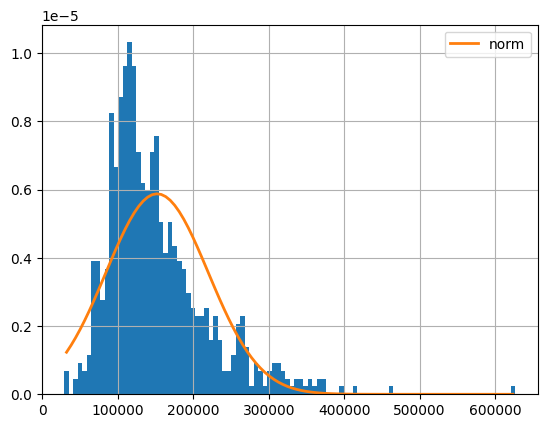

In [ ]:
# Initialize the Fitter object and specify the distributions to be fitted
f = Fitter(df_train_data.VacHomeSalePrice, distributions=["norm"])

# Fit the data to the specified distributions
f.fit()

# Print a summary of the fitted distributions
f.summary()

# Print the missing columns categorized by data type
print_pretty_header("Data Distribution for VacHomeSalePrice", "")


In [ ]:
# Print the missing columns categorized by data type
print_pretty_header("Best Distribution for VacHomeSalePrice", "")

# Get the best distribution based on the sum of squared errors
best_distribution = f.get_best(method='sumsquare_error')

# Print the best distribution
print(f"Best distribution: {best_distribution}")

####################################################################################################

                               Best Distribution for VacHomeSalePrice                               

####################################################################################################

Best distribution: {'norm': {'loc': 152003.62939726026, 'scale': 67913.78034365008}}


## 1.3. Exploratory Data Analysis - Structured Data


#### 1.3.1. Univariate analysis
First, let us check the univariate analysis. Typically, we do this for every column in the dataset. In the book, however, we will explore only the sale price variable as an example for you to explore the others.


##### 1.Measures of Frequency

###### 1.1 Frequency Count

In [ ]:
# Setting to display all columns in a single row
pd.set_option('display.max_columns', None)

# Make the Jupyter chunk window wider
# This code widens the display window in Jupyter Notebook
display(HTML("<style>.container { width:100% !important; }</style>"))

# Creating a DataFrame with the VacHomeBuilding column from another DataFrame
df_counts = pd.DataFrame(df_train_data['VacHomeBuilding'])

# Resetting the index of the df_counts DataFrame
df_counts.reset_index(inplace=True)  # Make sure to assign the result back to df_counts

# Grouping the df_counts DataFrame by the VacHomeBuilding column and counting the number of occurrences
df_counts_2 = df_counts.groupby(['VacHomeBuilding'])['VacHomeBuilding'].count()

# Creating a new DataFrame with the results of the groupby operation
results_df = pd.DataFrame(df_counts_2)

# Rename the column name directly to 'ColumnFrequency'
results_df.columns = ['ColumnValueFrequency']

# Sorting the DataFrame by 'VacHomeBuilding' in descending order
results_df = results_df.sort_values(by='ColumnValueFrequency', ascending=False)

# Print Header
print_pretty_header("Measures of Frequency", "Frequency counts or one-way tables")

# Displaying the results_df DataFrame as an HTML table in Jupyter Notebook with styled header and set column width
from IPython.display import HTML

# Define CSS styles for the header
header_styles = '''
    <style>
        .results_df th {
            background-color: lightgray;
            text-align: center;  /* Align header text to the center */
        }
    </style> '''

# Set the column width (adjust the value as needed)
col_width = '100px'

# Display the styled header and DataFrame with the specified column width
display(HTML(header_styles + results_df.to_html(classes="results_df", col_space=col_width)))


####################################################################################################

                                       Measures of Frequency                                        

                                 Frequency counts or one-way tables                                 

####################################################################################################



,ColumnValueFrequency
VacHomeBuilding,
Apartment,613
SingleFamilyHome,57
MultiFamilyHome,22
Condo,19
Townhome,19


######1.2. Counts Plot

####################################################################################################

                                       Measures of Frequency                                        

                                            Counts Plot                                             

####################################################################################################



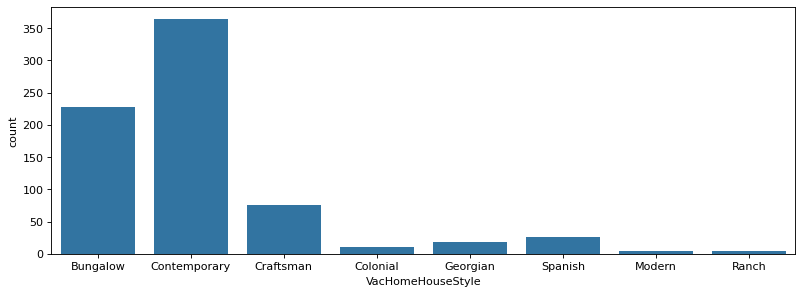

In [ ]:
# Create a DataFrame with the VacHomeHouseStyle column from another DataFrame
df_counts = pd.DataFrame(df_train_data.VacHomeHouseStyle)

# Reset the index of the df_counts DataFrame
df_counts.reset_index()

# Group the df_counts DataFrame by the VacHomeHouseStyle column and count the occurrences
df_counts_2 = df_counts.groupby(['VacHomeHouseStyle'])['VacHomeHouseStyle'].count()

# Rename the column in the df_counts_2 DataFrame to 'VacHomeHouseStyle_freq'
df_counts_2.columns =['VacHomeHouseStyle', 'VacHomeHouseStyle_freq']

# Create a figure and axis object with specific size and dpi
fig, ax = plt.subplots(figsize=(12,4), dpi= 80)

# Create a countplot of the VacHomeHouseStyle column in the df_counts DataFrame using the specified axis
sns.countplot(x="VacHomeHouseStyle",data=df_counts, ax=ax)

# Print Header
print_pretty_header("Measures of Frequency", "Counts Plot")
# Add title and show the plot
plt.title('', fontsize=10)
plt.show()


######1.3. Frequency Bins


In [ ]:
# Print Header
print_pretty_header("Measures of Frequency", "Frequency Bins (for VacHomeSalePrice)")

# Compute the frequency counts for VacHomeSalePrice values divided into 10 bins, and sort them by the bin's order value
freq_counts = df_train_data.VacHomeSalePrice.value_counts(bins=10).sort_index()

# Reset the index
freq_counts = freq_counts.reset_index()

# Rename the columns
freq_counts = freq_counts.rename(columns={'index': 'Sale Price Bins', 'VacHomeSalePrice': 'Count'})

# Display the frequency counts using an HTML table
from IPython.display import HTML
HTML(freq_counts.to_html(index=False))

####################################################################################################

                                       Measures of Frequency                                        

                               Frequency Bins (for VacHomeSalePrice)                                

####################################################################################################



Sale Price Bins,count
"(28375.316, 88741.3]",79
"(88741.3, 148509.6]",347
"(148509.6, 208277.9]",181
"(208277.9, 268046.2]",75
"(268046.2, 327814.5]",31
"(327814.5, 387582.8]",13
"(387582.8, 447351.1]",2
"(447351.1, 507119.4]",1
"(507119.4, 566887.7]",0
"(566887.7, 626656.0]",1


######1.4. Histogram


####################################################################################################

                                       Measures of Frequency                                        

                                  Histogram (for VacHomeSalePrice)                                  

####################################################################################################



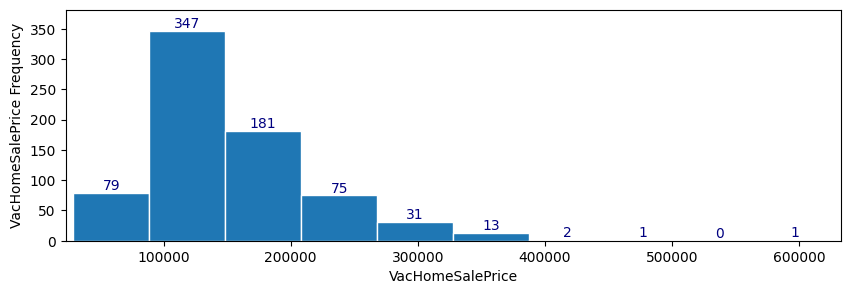

In [ ]:
# Print Header
print_pretty_header("Measures of Frequency", "Histogram (for VacHomeSalePrice)")

# Set the figure size and create a histogram of VacHomeSalePrice
plt.figure(figsize=(10, 3))
values, bins, bars = plt.hist(df_train_data.VacHomeSalePrice, edgecolor='white')

# Add labels for the x and y axis
plt.xlabel("VacHomeSalePrice",fontsize=10)
plt.ylabel("VacHomeSalePrice Frequency")

# Add value labels to the bars of the histogram
plt.bar_label(bars, fontsize=10, color='navy')

# Set the margins of the plot
plt.margins(x=0.01, y=0.1)

# Display the histogram
plt.show()

####################################################################################################

                                       Measures of Frequency                                        

                              Colored Histogram (for VacHomeSalePrice)                              

####################################################################################################



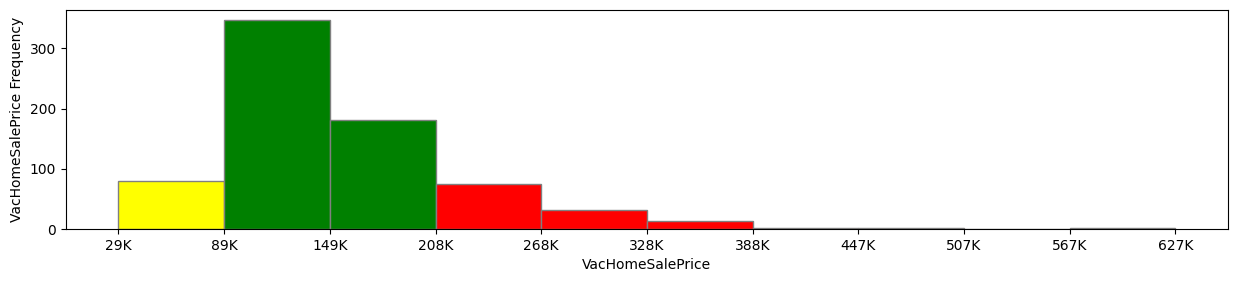

In [ ]:
# Print Header
print_pretty_header("Measures of Frequency", "Colored Histogram (for VacHomeSalePrice)")

# Assigning the data to a variable
data = df_train_data.VacHomeSalePrice

# Creating a figure and axes object
fig, ax = plt.subplots(figsize=(15, 3))

# Creating a histogram with green facecolor and gray edgecolor
counts, bins, patches = ax.hist(data, facecolor='green', edgecolor='gray')

# Set the ticks to be at the edges of the bins and format the x-axis labels
ax.set_xticks(bins)
ax.xaxis.set_major_formatter(FormatStrFormatter('$%d'))

# Change the colors of bars at the edges based on percentile values
twentyfive, seventyfive = np.percentile(data, [25, 75])
for patch, rightside, leftside in zip(patches, bins[1:], bins[:-1]):
    if rightside < twentyfive:
        patch.set_facecolor('yellow')
    elif leftside > seventyfive:
        patch.set_facecolor('red')

# Calculate the bin centers
bin_centers = 0.5 * np.diff(bins) + bins[:-1]

# Set the x and y labels and adjust the subplot bottom
plt.xlabel("VacHomeSalePrice", fontsize=10)
plt.ylabel("VacHomeSalePrice Frequency")
plt.subplots_adjust(bottom=0.15)

# Format the tick labels on the x-axis to display values like "10K", "50K", etc.
ax.set_xticklabels(['{:.0f}K'.format(x/1000) for x in ax.get_xticks()])

# Show the plot
plt.show()


######1.5. Ordered Bar Chart



####################################################################################################

                                       Measures of Frequency                                        

                                         Ordered Bar Chart                                          

####################################################################################################



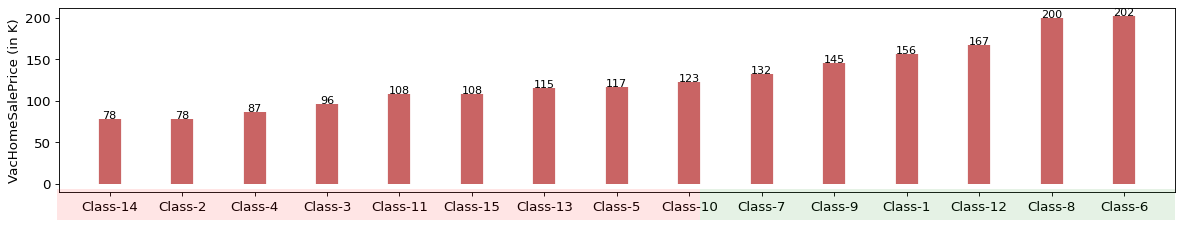

In [ ]:
# Print Header
print_pretty_header("Measures of Frequency", "Ordered Bar Chart")

# Set the locale to format numbers without decimals
locale.setlocale(locale.LC_ALL, 'en_US.UTF-8')

# Prepare Data
df = df_train_data[['VacHomeSalePrice', 'VacHomeClass']].groupby('VacHomeClass').apply(lambda x: x.mean())
df.sort_values('VacHomeSalePrice', inplace=True)
df.reset_index(inplace=True)

# Round the 'VacHomeSalePrice' column to thousands (K)
df['VacHomeSalePrice'] = df['VacHomeSalePrice'] // 1000

# Draw plot
fig, ax = plt.subplots(figsize=(18, 3), facecolor='white', dpi=80)
ax.vlines(x=df.index, ymin=0, ymax=df.VacHomeSalePrice, color='firebrick', alpha=0.7, linewidth=20)

# Annotate Text without decimals
for i, VacHomeSalePrice in enumerate(df.VacHomeSalePrice):
    label = locale.format_string('%d', VacHomeSalePrice, grouping=True)
    ax.text(i, VacHomeSalePrice + 0.5, label, horizontalalignment='center', fontsize=10)

# Title, Label, Ticks and Ylim
plt.xticks(df.index, df.VacHomeClass.str[7:], rotation=0, horizontalalignment='center', fontsize=12)

# Add patches to color the X axis labels
p1 = mpl.patches.Rectangle((.57, -0.005), width=.33, height=.13, alpha=.1, facecolor='green', transform=fig.transFigure)
p2 = mpl.patches.Rectangle((.124, -0.005), width=.446, height=.13, alpha=.1, facecolor='red', transform=fig.transFigure)
fig.add_artist(p1)
fig.add_artist(p2)

plt.ylabel('VacHomeSalePrice (in K)', fontsize=12)
plt.yticks(fontsize=12)

plt.show()


######1.6. Lollipop Chart

####################################################################################################

                                       Measures of Frequency                                        

                                           Lollipop Chart                                           

####################################################################################################



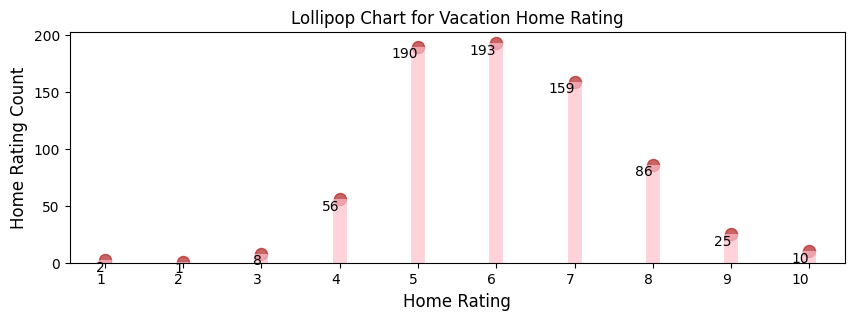

In [ ]:
# Print Header
print_pretty_header("Measures of Frequency", "Lollipop Chart")

# Create frequency table for 'VacHomeRating' column
df = df_train_data['VacHomeRating'].value_counts().reset_index()

# Rename columns for better readability
df.columns = ['VacHomeRating', 'VacHomeRating_freq']

# Sort data by rating in ascending order
df = df.sort_values(by="VacHomeRating", ascending=True)

# Draw plot
fig, ax = plt.subplots(figsize=(10, 3), dpi= 100)
ax.vlines(x=df.VacHomeRating, ymin=0, ymax=df.VacHomeRating_freq, color='pink', alpha=0.7, linewidth=10)
ax.scatter(x=df.VacHomeRating, y=df.VacHomeRating_freq, s=75, color='firebrick', alpha=0.7)

# Set plot title, labels, ticks and y-axis limit
ax.set_title('Lollipop Chart for Vacation Home Rating', fontdict={'size':12})
ax.set_ylabel('Home Rating Count', fontsize=12)
ax.set_xlabel('Home Rating', fontsize=12)
ax.set_xticks(df.VacHomeRating)
ax.set_xticklabels(df.VacHomeRating, rotation=0, fontdict={'horizontalalignment': 'right', 'size':10})
ax.tick_params(axis='y', labelsize=10)
ax.set_ylim(0, max(df.VacHomeRating_freq) + 10)

# Annotate plot with frequency values
for row in df.itertuples():
    ax.text(row.VacHomeRating, row.VacHomeRating_freq, s='{:,.0f}'.format(row.VacHomeRating_freq),
            horizontalalignment= 'right', verticalalignment='top', fontsize=10)

plt.show()


##### 2.Measures of Central Tendency
Okay, next we run Summary analysis on all numeric continuous fields. On the SalePrice field, we get the following for Measures of Central Tendency.
Here, it seems to be clear that the mean is way higher than the median. So we should anticipate some outliers with high values.



######2.1. Summary Statistics

In [ ]:
# Print Header
print_pretty_header("Measures of Central Tendency", "Summary Statistics")

import statistics
# 20a. Arithmetic Mean
print("Arithmetic Mean: " ,  round(df_train_data.VacHomeSalePrice.mean(),0))

# 20b. Median
print("Median         : " , round(df_train_data.VacHomeSalePrice.median(),0))

# 20c. Mode
print("Mode           : " ,statistics.mode(df_train_data.VacHomeSalePrice) )


####################################################################################################

                                    Measures of Central Tendency                                    

                                         Summary Statistics                                         

####################################################################################################

Arithmetic Mean:  152004.0
Median         :  135914.0
Mode           :  116206.0


######2.2. Box and Whisker Plot

####################################################################################################

                                    Measures of Central Tendency                                    

                                        Box and Whisker Plot                                        

####################################################################################################



[Text(0.5, 1.0, 'VacHome SalePrice')]

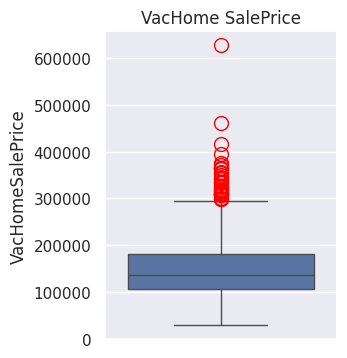

In [ ]:
# Print Header
print_pretty_header("Measures of Central Tendency", "Box and Whisker Plot")

# Set the figure size
sns.set(rc={'figure.figsize':(3,4)})

# Define the properties of the outliers in the boxplot
flierprops = dict(marker='o', markerfacecolor='None', markersize=10, markeredgecolor='red')

# Create a boxplot of VacHomeSalePrice and set the title
sns.boxplot(y=df_train_data.VacHomeSalePrice,flierprops=flierprops).set(title='VacHome SalePrice')


##### 3.Measures of Dispersion




i. Range, Variance, and Std Dev

In [ ]:
# Calculate measures of dispersion
saleprice_std = df_train_data['VacHomeSalePrice'].std()
saleprice_var = df_train_data['VacHomeSalePrice'].var()
saleprice_range = df_train_data['VacHomeSalePrice'].max() - df_train_data['VacHomeSalePrice'].min()

# Print Header
print_pretty_header("Measures of Dispersion", "Summary")

print(f"Standard Deviation: {saleprice_std:,.2f}")
print(f"Variance          : {saleprice_var:,.2f}")
print(f"Range             : {saleprice_range:,.2f}")


####################################################################################################

                                       Measures of Dispersion                                       

                                              Summary                                               

####################################################################################################

Standard Deviation: 67,960.34
Variance          : 4,618,608,421.42
Range             : 597,683.00


######3.1. Univariate Scatter Plot


####################################################################################################

                                       Measures of Dispersion                                       

                                            Scatter plot                                            

####################################################################################################



<ipython-input-24-e9d97db35f01>:7: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(df_rawdata.index, df_rawdata.VacHomeSalePrice, s=area, c=colors, alpha=0.5)


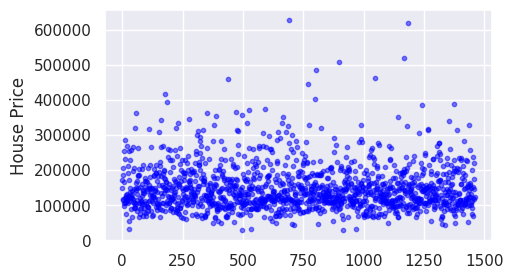

In [ ]:
# Define colors and size of markers
colors = (0,0,1)
area = np.pi*3

# Create scatter plot
fig, ax = plt.subplots(figsize=(5,3))
ax.scatter(df_rawdata.index, df_rawdata.VacHomeSalePrice, s=area, c=colors, alpha=0.5)

# Print Header
print_pretty_header("Measures of Dispersion", "Scatter plot")

# Add title and labels
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('House Price')

# Display plot
plt.show()


##### 4.Measures of Shape




######4.1. Skewness and Kurtosis


In [ ]:
# Print Measure of Shape of VacHomeSalePrice

# Print Header
print_pretty_header("Measures of Shape", "Skewness & Kurtosis")

# Calculate Asymmetry (Skewness) of VacHomeSalePrice
print("Skewness          : " , round(skew(df_train_data.VacHomeSalePrice, axis=0, bias=True),2))

# Calculate Peakedness (Kurtosis) of VacHomeSalePrice
print("Kurtosis          : " , round(kurtosis(df_train_data.VacHomeSalePrice, axis=0, bias=True),2))

####################################################################################################

                                         Measures of Shape                                          

                                        Skewness & Kurtosis                                         

####################################################################################################

Skewness          :  1.58
Kurtosis          :  4.41


######4.2.Density Plot


####################################################################################################

                                         Measures of Shape                                          

                                            Density Plot                                            

####################################################################################################



<ipython-input-26-cc4c4a572107>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train_data['VacHomeSalePrice'], hist=True, kde=True,


<Axes: xlabel='VacHomeSalePrice', ylabel='Density'>

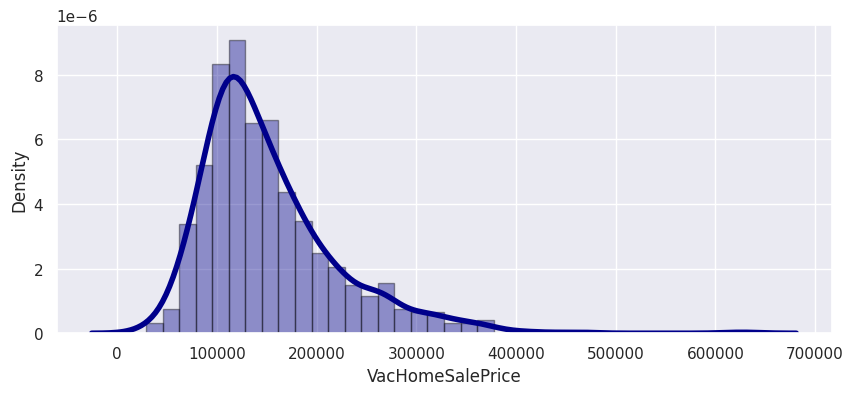

In [ ]:
# Print Header
print_pretty_header("Measures of Shape", "Density Plot")

# Density Plot and Histogram of all arrival delays
sns.set(rc={'figure.figsize':(10,4)}) # Set the figure size
sns.distplot(df_train_data['VacHomeSalePrice'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4}) # Create the distribution plot


##### 5.Measures of Position

######5.1. Percentile, Quartile


In [ ]:
# Print Header
print_pretty_header("Measures of Position", "Percentiles")

# Print table headers
print("----------  -----------------")
print("Percentile  VacHomeSalePrice")
print("----------  -----------------")

# Sort the values in ascending order
df_train_data = df_train_data.sort_values(by=['VacHomeSalePrice'], ascending=True)

# Calculate the percentiles
percentiles = [0.1, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 1]

# Pretty print the percentiles and VacHomeSalePrice
for percentile in percentiles:
    value = df_train_data['VacHomeSalePrice'].quantile(percentile)
    print(f"{percentile:.2f}            {value:.2f}")

####################################################################################################

                                        Measures of Position                                        

                                            Percentiles                                             

####################################################################################################

----------  -----------------
Percentile  VacHomeSalePrice
----------  -----------------
0.10            87073.00
0.25            107044.88
0.50            135914.35
0.75            181776.00
0.90            246848.00
0.95            285475.66
0.99            363802.02
1.00            626656.00


#### 1.3.2. Bivariate analysis
Now, let us check the bivariate analysis. Typically, we do this for every column combination in the dataset. In the book, however, we will explore only the sale price variable with the HouseStyle as an example for you to explore the others.

#####6.Measures of Association



######6.1. Two-way contingency table

In [ ]:
# Print Header
print_pretty_header("Measures of Association", "Two-Way Contingency Tables")

# Create a two-way contingency table
contingency_table = pd.crosstab(df_train_data['VacHomeGoodSchools'], df_train_data['VacHomeInterestInHome'], rownames=['Good Schools'], colnames=['Interested in Home'])

# Reorder rows and columns
contingency_table = contingency_table.reindex(index=['Y', 'N'], columns=['Y', 'N'])

# Print the contingency table
print(contingency_table)



####################################################################################################

                                      Measures of Association                                       

                                     Two-Way Contingency Tables                                     

####################################################################################################

Interested in Home    Y    N
Good Schools                
Y                   169  190
N                   205  166


######6.2. Odds Ratio

In [ ]:
print_pretty_header("Measures of Association", "Odds Ratio")

df_table_data = pd.DataFrame(contingency_table)

oddsratio, pvalue = stats.fisher_exact(df_table_data)
print("Odds Ratio of GoodSchools to InterestInHome : ", round(oddsratio,2))


####################################################################################################

                                      Measures of Association                                       

                                             Odds Ratio                                             

####################################################################################################

Odds Ratio of GoodSchools to InterestInHome :  0.72


######6.3 Cramer's V

In [ ]:
def cramers_v(confusion_matrix):
    try:
        confusion_matrix = np.array(confusion_matrix)
        chi2 = chi2_contingency(confusion_matrix)[0]
        n = confusion_matrix.sum()
        phi2 = chi2/n
        r, k = confusion_matrix.shape
        phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
        rcorr = r - ((r-1)**2)/(n-1)
        kcorr = k - ((k-1)**2)/(n-1)
        return np.sqrt(phi2corr/min((kcorr-1), (rcorr-1)))
    except Exception as e:
        logging.error(f"Failed to create cramers_v: {e}")
        raise
        return None

# Run Cramer's V
contingency_table = pd.crosstab(df_train_data['VacHomeLotConfig'], df_train_data['VacHomeLandSlope'])
cramers_v_val = cramers_v(contingency_table)
print_pretty_header("Measures of Association", "Cramer's V")
print("Cramer's V:", round(cramers_v_val,3))

####################################################################################################

                                      Measures of Association                                       

                                             Cramer's V                                             

####################################################################################################

Cramer's V: 0.098


######6.4 Phi coefficient

In [ ]:
def phi_coefficient(crosstab):
    try:
        # Convert crosstab to a 2x2 numpy array
        confusion_matrix = np.array(crosstab)

        # Check if crosstab is a 2x2 table
        if confusion_matrix.shape != (2, 2):
            raise ValueError("Crosstab must be a 2x2 table")

        # Calculate values needed for the phi coefficient
        a = confusion_matrix[0, 0]
        b = confusion_matrix[0, 1]
        c = confusion_matrix[1, 0]
        d = confusion_matrix[1, 1]
        n = a + b + c + d
        ad_bc = (a * d) - (b * c)
        s = np.sqrt((a + b) * (c + d) * (a + c) * (b + d))

        # Calculate the phi coefficient
        if ad_bc == 0 or s == 0:
            return 0
        else:
            return ad_bc / s
    except Exception as e:
        logging.error(f"Failed to compute phi coefficient: {e}")
        raise
        return None

# Example usage
contingency_table = pd.crosstab(df_train_data['VacHomeGoodSchools'], df_train_data['VacHomeInterestInHome'])

# Print Header
print_pretty_header("Measures of Association", "Phi coefficient")
phi = phi_coefficient(contingency_table)
print("Phi coefficient:", round(phi,3))


####################################################################################################

                                      Measures of Association                                       

                                          Phi coefficient                                           

####################################################################################################

Phi coefficient: -0.082


######6.5. Chi-Squared test of Independence

In [ ]:
# Assign variables for the columns we want to test for association
variable1 = "VacHomeGoodSchools"
variable2 = "VacHomeInterestInHome"

# Create a contingency table and calculate chi-squared statistic, p-value, and degree of freedom
chisqt = pd.crosstab(df_train_data['VacHomeGoodSchools'], df_train_data['VacHomeInterestInHome'], margins=True)
value = np.array([chisqt.iloc[0][0:5].values, chisqt.iloc[1][0:5].values])
chi_sq_stat, p_value, dof, _ = chi2_contingency(value)

# Print Header
print_pretty_header("Measures of Association", "Chi-Squared test of Independence")

# Print the results
print("Chi-Sq.           : ", chi_sq_stat)
print("p-value.          : ", p_value)
print("Degree of Freedom : ", dof)

# Interpret the results based on the p-value
if p_value > 0.05:
    print("We accept the null hypothesis and assume that the variables", variable1, "and", variable2, "are independent of each other.")
else:
    print("We reject the null hypothesis and assume that the variables", variable1, "and", variable2, "are not independent of each other.")


####################################################################################################

                                      Measures of Association                                       

                                  Chi-Squared test of Independence                                  

####################################################################################################

Chi-Sq.           :  4.887278534051263
p-value.          :  0.08684422634046736
Degree of Freedom :  2
We accept the null hypothesis and assume that the variables VacHomeGoodSchools and VacHomeInterestInHome are independent of each other.


######6.6. Clustered bar chart

####################################################################################################

                                      Measures of Association                                       

                            Clustered Bar Chart with Contingency Matrix                             

####################################################################################################



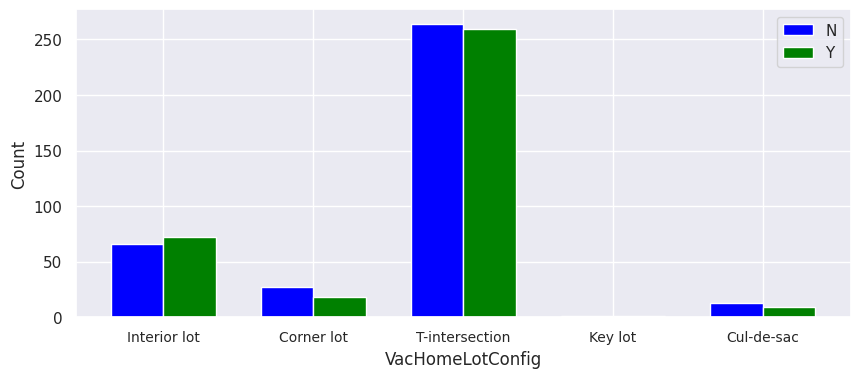

In [ ]:
# Load the data and create the contingency table
contingency_table = pd.crosstab(df_train_data['VacHomeLotConfig'], df_train_data['VacHomeLandSlope'])

# Get the unique categories for the x-axis and group labels for the legend
categories = df_train_data['VacHomeLotConfig'].unique()
group_labels = df_train_data['VacHomeGoodSchools'].unique()

# Create the contingency matrix using crosstab and numpy
contingency_matrix = np.array(pd.crosstab(df_train_data['VacHomeGoodSchools'], df_train_data['VacHomeLotConfig']))

# Set the bar width
bar_width = 0.35

# Set the positions of the bars on the x-axis
r1 = np.arange(len(categories))
r2 = [x + bar_width for x in r1]

# Create the bar chart
plt.bar(r1, contingency_matrix[0], color='blue', width=bar_width, edgecolor='white', label=group_labels[0])
plt.bar(r2, contingency_matrix[1], color='green', width=bar_width, edgecolor='white', label=group_labels[1])

# Add x-axis labels and title
plt.xlabel('VacHomeLotConfig', fontsize=12)
plt.xticks([r + bar_width/2 for r in range(len(categories))], categories, fontsize=10)
plt.ylabel('Count')
plt.title('')

# Print Header
print_pretty_header("Measures of Association", "Clustered Bar Chart with Contingency Matrix")

# Add a legend
plt.legend()

# Show the plot
plt.show()


In [ ]:
# import pandas as pd
# from tabulate import tabulate

# # Load your data into the DataFrame df_train_data

# # Create the contingency table
# contingency_table = pd.crosstab(df_train_data['VacHomeLotConfig'], df_train_data['VacHomeGoodSchools'])

# # Print the contingency table using tabulate
# table = tabulate(contingency_table, headers='keys', tablefmt='pretty')
# print(table)


######6.7. Mosaic Plot

####################################################################################################

                                      Measures of Association                                       

                                            Mosaic Plot                                             

####################################################################################################



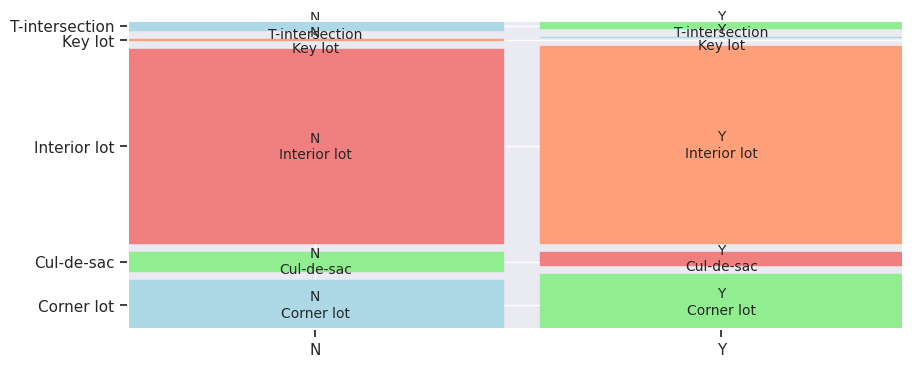

In [ ]:
# Assuming you have loaded your data into df_train_data

# Get the unique values for the `VacHomeLotConfig` and `VacHomeGoodSchools` columns
categories = df_train_data['VacHomeLotConfig'].unique()
group_labels = df_train_data['VacHomeGoodSchools'].unique()

# Create a contingency table and convert it to a DataFrame
contingency_table = pd.crosstab(df_train_data['VacHomeGoodSchools'], df_train_data['VacHomeLotConfig'])

# Define a color palette for the segments
colors = cycle(['lightblue', 'lightgreen', 'lightcoral', 'lightsalmon'])

# Print Header
print_pretty_header("Measures of Association", "Mosaic Plot")

# Create a mosaic plot with custom colors and no labels
mosaic(
    contingency_table.stack(),
    gap=0.05,
    title='',
    labelizer=None,
    properties=lambda key: {'color': next(colors)}  # Assign colors from the palette
)

# Display the plot
plt.show()


#####7.Measures of Correlation

######7.1 Covariance

In [ ]:
# Define a function to calculate covariance between two variables
def covariance(x, y):
    try:
        # Calculate the mean of the two input series
        mean_x = sum(x)/float(len(x))
        mean_y = sum(y)/float(len(y))
        # Subtract the mean from each element in the series
        sub_x = [i - mean_x for i in x]
        sub_y = [i - mean_y for i in y]
        # Calculate the numerator of the covariance formula
        numerator = sum([sub_x[i]*sub_y[i] for i in range(len(sub_x))])
        # Calculate the denominator of the covariance formula
        denominator = len(x)-1
        # Calculate covariance as the numerator divided by the denominator
        cov = numerator/denominator
        # Return the covariance value
        return cov
    except Exception as e:
        logging.error(f"Failed to calculate covariance between two variables: {e}")
        raise
        return None

# Call the covariance function with two variables and print the result
cov_func = covariance(df_train_data.VacHomeSqFt, df_train_data.VacHomeSalePrice)

# Print Header
print_pretty_header("Measures of Correlation", "Covariance")

print("Covariance :", round(cov_func,2))


####################################################################################################

                                      Measures of Correlation                                       

                                             Covariance                                             

####################################################################################################

Covariance : 26359256.66


######7.2. Pearson’s correlation coefficient

In [ ]:
# Define a list of columns you want to include in the correlation analysis
columns_to_include = ['VacHomePoolSqFt', 'VacHomeCarsInGarage', 'VacHomeSqFt', 'VacHomeBsmtSqFt', 'VacHomeSalePrice']  # Replace with your column names

# Filter the dataset to include only the selected columns
df_filtered = df_train_data[columns_to_include]

# Calculate the correlation matrix for the selected columns
correlation_matrix = df_filtered.corr()

# Define a function to filter the correlation matrix for Pearson’s correlation coefficient greater than a given bound
def corrFilter(data, bound: float):
    try:
        # Filter the correlation matrix for values greater than or equal to the bound and not equal to 1
        xFiltered = data[((data >= bound) ) & (data != 1.000)]
        # Unstack the filtered matrix, sort it in descending order and drop duplicate values
        xFlattened = xFiltered.unstack().sort_values(ascending=False).drop_duplicates()
        # Return the flattened, sorted and deduplicated correlation values
        return xFlattened
    except Exception as e:
        logging.error(f"Failed to get data: {e}")
        raise
        return None

# Filter the correlation matrix of the selected columns for values greater than or equal to 0.3
high_corr = corrFilter(correlation_matrix, 0.3)

# Print Header
print_pretty_header("Measures of Correlation", "Pearson’s correlation coefficient")

# Convert the filtered and flattened correlation values to a DataFrame
high_corr_df = pd.DataFrame(high_corr)

# Display the DataFrame
high_corr_df


####################################################################################################

                                      Measures of Correlation                                       

                                 Pearson’s correlation coefficient                                  

####################################################################################################



0
VacHomeSqFt         VacHomeSalePrice  0.739039
VacHomeCarsInGarage VacHomeSalePrice  0.676448
VacHomeBsmtSqFt     VacHomeSalePrice  0.657199
VacHomeCarsInGarage VacHomeSqFt       0.515835
                    VacHomeBsmtSqFt   0.482014
VacHomeSqFt         VacHomeBsmtSqFt   0.475390
VacHomePoolSqFt     VacHomePoolSqFt        NaN

######7.3. Spearman R correlation coefficient

In [ ]:
variable1 = "VacHomeQuality"
variable2 = "VacHomeRating"

# Calculate the Spearman correlation coefficient and the p-value between the two variables
spearmanr = stats.spearmanr(df_rawdata['VacHomeQuality'], df_rawdata['VacHomeRating'])

# Print Header
print_pretty_header("Measures of Correlation", "Spearman correlation coefficient")

# Print the results
print("Spearmanr           : " , spearmanr[0])
print("p-value.          : " , spearmanr[1])
print("")
# Interpret the results based on the value of the Spearman correlation coefficient
if spearmanr[0] > 1:
    print("For" , variable1 , "and"  , variable2 ,  ": Strongly Agree values tend to occur together")
elif spearmanr[0] < 1:
    print("Strongly Agree values for" , variable1 , "tend to coincide with Strongly Disagree on"  , variable2)
else:
    print("The value of one Likert item does not predict the other Likert item’s value. There is no relationship between them." )


####################################################################################################

                                      Measures of Correlation                                       

                                  Spearman correlation coefficient                                  

####################################################################################################

Spearmanr           :  -0.17752065840995482
p-value.          :  8.398835320074494e-12

Strongly Agree values for VacHomeQuality tend to coincide with Strongly Disagree on VacHomeRating


######7.4. Pair Plot

####################################################################################################

                                      Measures of Correlation                                       

                                             Pair Plot                                              

####################################################################################################



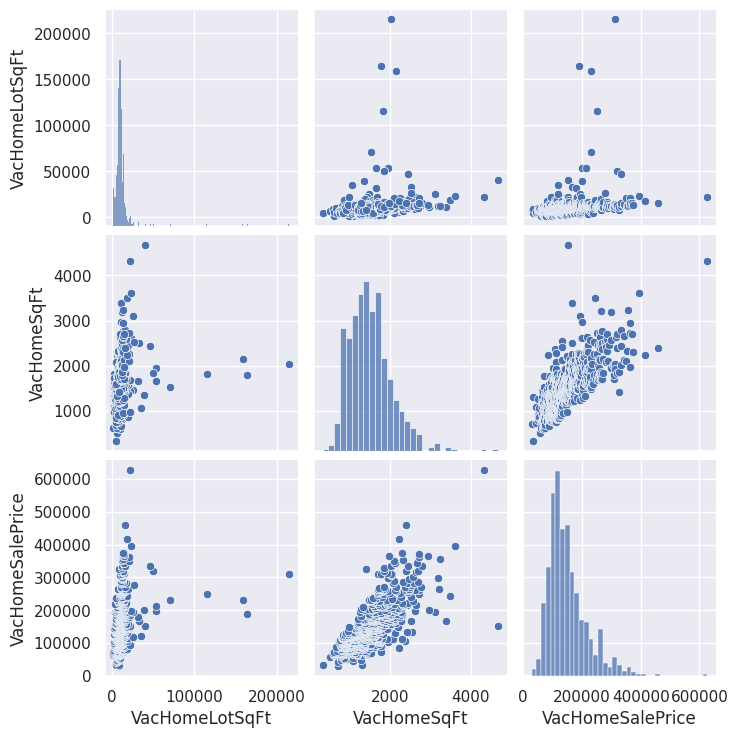

In [ ]:
# Print Header
print_pretty_header("Measures of Correlation", "Pair Plot")

sns.pairplot(df_train_data, vars=['VacHomeLotSqFt','VacHomeSqFt','VacHomeSalePrice'])

######7.5. Heat Map

####################################################################################################

                                      Measures of Correlation                                       

                                              Heat Map                                              

####################################################################################################



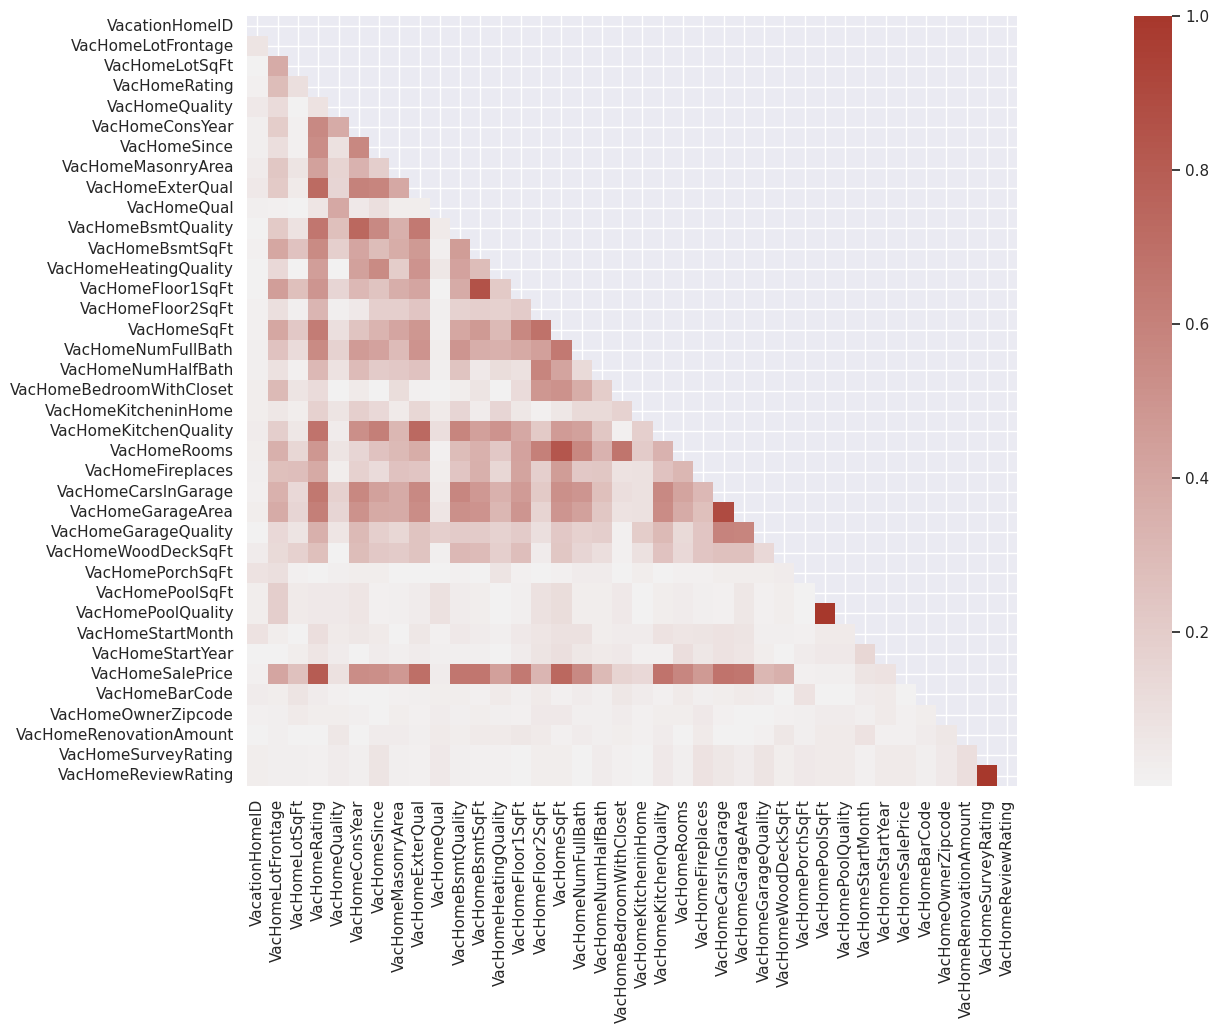

In [ ]:
# Step 2: Select numerical columns
df_rawdata_num = df_train_data.select_dtypes(include='number')

# Step 3: Calculate the correlation matrix
matrix = df_rawdata_num.corr().abs()
mask = np.triu(np.ones_like(matrix, dtype=bool))
reduced_matrix = matrix.mask(mask)

# Step 4: Create a mask
plt.figure(figsize=(30, 10))
mask = np.triu(np.ones_like(matrix, dtype=bool))

# Step 5: Create a custom diverging palette
cmap = sns.diverging_palette(250, 15, s=75, l=40, n=9, center="light", as_cmap=True)

# Plot the heatmap
sns.heatmap(reduced_matrix, mask=mask, center=0, annot=False, fmt='.2f', square=True, cmap=cmap)

# Print Header
print_pretty_header("Measures of Correlation", "Heat Map")

# Show the plot
plt.show()

#####8.Measures of Composition

######8.1. Ratio

In [ ]:
# Extracting specific columns from the training data and creating a DataFrame
df_counts = pd.DataFrame(df_train_data[["VacHomeHouseStyle","VacHomeSqFt","VacHomeBsmtSqFt"]])

# Grouping the DataFrame by 'VacHomeHouseStyle' and calculating the sum of 'VacHomeSqFt' and 'VacHomeBsmtSqFt' for each group
df_counts = pd.DataFrame(df_counts.groupby(by=["VacHomeHouseStyle"], dropna=False)[['VacHomeSqFt','VacHomeBsmtSqFt']].sum())

# Calculating the ratio of basement area to total area for each house style and adding it as a new column
df_counts['Ratio'] = round((df_counts.VacHomeBsmtSqFt / df_counts.VacHomeSqFt),2)

# Printing header
print_pretty_header("Measures of Composition", "Ratio")

# Resetting the index of the DataFrame and renaming columns for clarity
df_counts.reset_index(inplace=True)
df_counts.columns =['VacHomeHouseStyle', 'VacHomeSqFt','VacHomeBsmtSqFt','VacHomeBsmtSqFt_to_VacHomeSqFt_Ratio']

# Displaying the final DataFrame
df_counts


####################################################################################################

                                      Measures of Composition                                       

                                               Ratio                                                

####################################################################################################



,VacHomeHouseStyle,VacHomeSqFt,VacHomeBsmtSqFt,VacHomeBsmtSqFt_to_VacHomeSqFt_Ratio
0,Bungalow,426729,214049,0.50
1,Colonial,9921,8995,0.91
2,Contemporary,477342,444923,0.93
3,Craftsman,113272,64820,0.57
4,Georgian,17165,14768,0.86
5,Modern,8311,3825,0.46
6,Ranch,14917,5492,0.37
7,Spanish,37523,24720,0.66


######8.2. Proportion

In [ ]:
# create a new DataFrame with only two columns: VacHomeHouseStyle and VacHomeSalePrice
df_counts = pd.DataFrame(df_train_data[["VacHomeHouseStyle","VacHomeSalePrice"]])

# group the DataFrame by VacHomeHouseStyle and sum the VacHomeSalePrice for each group
df_counts = pd.DataFrame(df_counts.groupby(by=["VacHomeHouseStyle"], dropna=False).VacHomeSalePrice.sum())

# convert the VacHomeSalePrice column to integers and rename it to SalePrice
df_counts["SalePrice"] = pd.to_numeric(df_counts["VacHomeSalePrice"]).astype('int')

# calculate the percentage of each group's total SalePrice and add it to a new column
df_counts['Percent'] = [round(i*100/sum(df_counts.VacHomeSalePrice),1) for i in df_counts.VacHomeSalePrice]

# reset the index so that VacHomeHouseStyle becomes a regular column and not the index
df_counts.drop(columns=['VacHomeSalePrice'], inplace=True)
df_counts.reset_index(inplace=True)

# Print Header
print_pretty_header("Measures of Composition", "Proportion")

# Rename the columns for clarity
df_counts.columns =['VacHomeHouseStyle','VacHomeSalePrice','SalePrice_Proportion']
df_counts

####################################################################################################

                                      Measures of Composition                                       

                                             Proportion                                             

####################################################################################################



,VacHomeHouseStyle,VacHomeSalePrice,SalePrice_Proportion
0,Bungalow,39992818,36.0
1,Colonial,976644,0.9
2,Contemporary,53818561,48.5
3,Craftsman,8805984,7.9
4,Georgian,1997168,1.8
5,Modern,642776,0.6
6,Ranch,1040435,0.9
7,Spanish,3688261,3.3


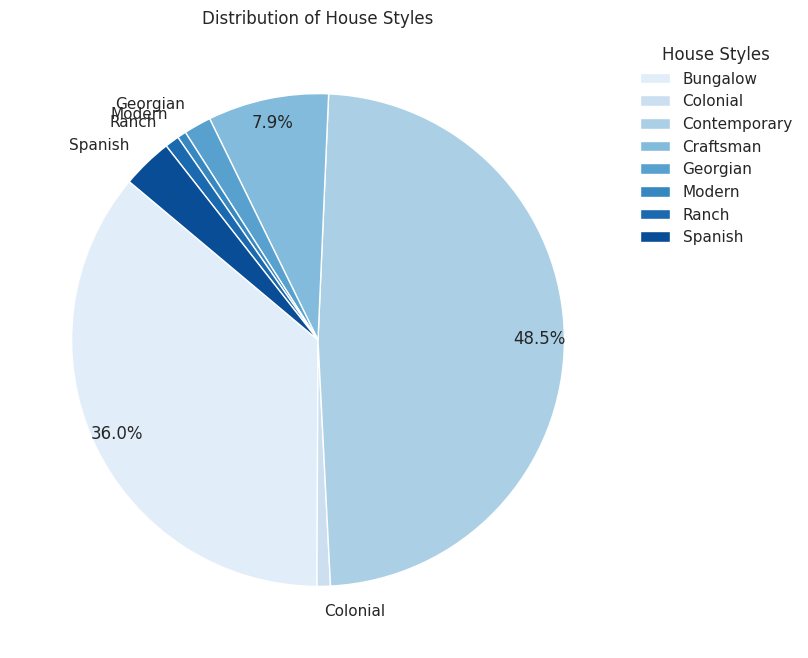

In [ ]:
# Create a custom color palette
pal_ = sns.color_palette(palette='Blues', n_colors=len(df_counts.VacHomeHouseStyle))

# Data for the pie chart (replace with your own data)
labels = df_counts.VacHomeHouseStyle
sizes = df_counts.VacHomeSalePrice

# Create the pie chart
fig, ax = plt.subplots(figsize=(8, 8))  # Set the figure size
wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=pal_, autopct='', pctdistance=0.9, startangle=140)

# Add a legend
ax.legend(wedges, labels, title="House Styles", bbox_to_anchor=(1, 1), loc=2, frameon=False)

# Add a title
ax.set_title("Distribution of House Styles")

# Set custom labels with percentages only when they fit
for text, autotext, size in zip(texts, autotexts, sizes):
    percentage = size / sum(sizes) * 100
    if percentage > 5:  # Adjust the threshold as needed
        text.set_text('')
        autotext.set_text(f'{percentage:.1f}%')

# Display the pie chart
plt.show()


In [ ]:
#  data and variables
x_var, y_var = "VacHomeLotShape", "VacHomeLotConfig"

# Group data by x_var and count the number of occurrences of y_var for each x_var value
df_grouped = df_train_data.groupby(x_var)[y_var].value_counts(normalize=True).unstack(y_var)

# Get a color list for the bar chart using Seaborn color palette
color_palette = list(sns.color_palette(palette='Blues', n_colors=len(df_grouped.columns)).as_hex())

# Create text labels with percentages
text_labels = (df_grouped * 100).round(1).astype(str) + '%'

# Create a 100% stacked bar chart using Plotly with custom colors and text labels
fig = px.bar(
    df_grouped,
    orientation="h",
    color_discrete_sequence=color_palette,  # Set custom colors
    text=text_labels.values.tolist()  # Set text labels
)

# Set figure size
fig.update_layout(width=800, height=500)

# Add axis labels
fig.update_xaxes(title_text=x_var)
fig.update_yaxes(title_text="")

# Add a chart title
fig.update_layout(
    title="",
    title_x=0.5  # Center the title
)
# Print Header
print_pretty_header("Measures of Composition", "100% Stacked Bar")

fig.show()


####################################################################################################

                                      Measures of Composition                                       

                                          100% Stacked Bar                                          

####################################################################################################



#####9.Measures of Divergence

There is intentionally no code in this section

#### 1.3.3. Multivariate analysis


#####10.Measures of Multicollinearity


There is intentionally no code in this section. Covered in pertinent chapters in Section 3

------------- End of S2_Ch5_Data_Comprehension_Code Chapter Code ------------ Vidya Subramanian ------------------